# Overview - Welcome to week 2 practical (coding part)

In this practical, you will develop a clearer understanding of how to work with columns in a pandas DataFrame. You will practise selecting single and multiple columns, explore the intuitive difference between a Series and a DataFrame, and perform simple column operations to create new values. You will also compute basic summary statistics to better understand the data. Finally, you will produce your first simple visualisation using matplotlib to help you see patterns in the data.

## 🐍 Python Libraries We'll Use

- **[pandas](https://pypi.org/project/pandas/)** - a Python package that provides fast, flexible, and expressive data structures designed to make working with "relational" or "labeled" data both easy and intuitive.

- **[Matplotlib](https://matplotlib.org/stable/index.html)** - Matplotlib is a low level graph plotting library in python that serves as a visualization utility.

In [1]:
# Please import before using.
import pandas as pd
import matplotlib.pyplot as plt

## 📊 Dataset We'll Use

In this practical, we will use the well-known **[Iris dataset](https://archive.ics.uci.edu/dataset/53/iris)**. The Iris dataset is a classic and widely used dataset in data science and machine learning for practising data analysis and visualisation. It contains measurements of iris flowers from three different species and is often used for learning how to explore and understand tabular data.

The Iris dataset can be obtained from many sources online. For convenience, a CSV version of the dataset has been provided on *iLearn* for you to download and use in this practical.

In [2]:
# Download the dataset from iLearn and load it.
iris_df = pd.read_csv('iris.csv')

In [3]:
# Let's quickly take a look at the data first.
# Displaying first few rows of the dataframe
print(iris_df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


# Selecting columns from a DataFrame

Data scientists often need to work with specific columns rather than the entire DataFrame.

The Iris dataset contains 4 numerical measurements and one categorical column (species). Selecting columns allows us to analyse particular features of the data.

In [4]:
# Let’s first preview the column names
print(iris_df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


## Selecting a Single Column

To select one column, use single square brackets:

In [5]:
# To avoid printing excessively long lines,
# we use the `head` method to display only the first few lines.
iris_df["sepal_length"].head()

0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: sepal_length, dtype: float64

✅ This returns a Series (a one-dimensional structure). We can check the type of confirm:

In [50]:
# You should see: 'pandas.core.series.Series'
print(type(iris_df["sepal_length"]))

<class 'pandas.core.series.Series'>


### 🧑‍🎓Your turn:

Select the petal_width column and display the first 5 rows.

In [6]:
# Your code here ...
iris_df['petal_length'].head()

0    1.4
1    1.4
2    1.3
3    1.5
4    1.4
Name: petal_length, dtype: float64

Select the species column and display the last 3 rows.

In [8]:
# Your code here ...
iris_df['species'].tail(3)

147    Virginica
148    Virginica
149    Virginica
Name: species, dtype: object

## Selecting Multiple Columns

To select more than one column, use double square brackets:

In [9]:
# Again, to avoid printing excessively long lines,
# we use the `head` method to display only the first few lines.
iris_df[["sepal_length", "petal_length"]].head()

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4


✅ This returns a DataFrame. We can print the type to confirm:

In [10]:
# You should see: 'pandas.core.frame.DataFrame'
print(type(iris_df[["sepal_length", "petal_length"]]))

<class 'pandas.core.frame.DataFrame'>


### 🧑‍🎓Your turn:

Select both sepal_width and petal_width and display the first 5 rows.

In [11]:
iris_df[["sepal_width", "petal_width"]].head(5)

,sepal_width,petal_width
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2
3,3.1,0.2
4,3.6,0.2


# Series vs DataFrame

**What is a Series?**

A Series is a one-dimensional labelled array.
You can think of it as a single column of data.

In [12]:
# For example:
# We extract `sepal_length` from `iris_df` and
# store it in the variable `sepal_length_series`
sepal_length_series = iris_df["sepal_length"]
sepal_length_series.head()

0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: sepal_length, dtype: float64

Check its shape:

In [13]:
# ✅ You should see something like: (150,)
sepal_length_series.shape

(150,)

**What is a DataFrame?**

A DataFrame is a two-dimensional table with rows and columns.

Please note that *this table can also contain only one column of data.*

In [14]:
# For example:
# We extract `sepal_length` from `iris_df` using double []
# store it in the variable `sepal_length_df`
sepal_length_df = iris_df[["sepal_length"]]
sepal_length_df.head()

,sepal_length
0,5.1
1,4.9
2,4.7
3,4.6
4,5.0


Check its shape:

In [15]:
# ✅ You should see something like: (150, 1)
sepal_length_df.shape

(150, 1)

You should observe:

**Series** → one column as a vector

**DataFrame** → table

## 🧑‍🎓Your turn:

Create a dataframe named 'petal_data' with both petal_width and petal_length, and print the shape of the dataframe - 'petal_data'.

In [16]:
# Your code here ...
petal_data = iris_df[['petal_width', 'petal_length']]

petal_data.shape

(150, 2)

# Simple column operations

One powerful feature of pandas is that we can *perform operations directly on columns*. Because columns behave like arrays of values, we can apply mathematical and logical operations to an entire column at once.

This makes data transformation fast and concise.

## Column Arithmetic

We can perform basic arithmetic operations on numeric columns.

For example, suppose we want to create a new column that doubles the sepal length:

In [61]:
# The following operation
# will add the newly calculated sepal_length_double column
# to the existing data frame.
iris_df["sepal_length_double"] = iris_df["sepal_length"] * 2
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_length_double
0,5.1,3.5,1.4,0.2,Setosa,10.2
1,4.9,3.0,1.4,0.2,Setosa,9.8
2,4.7,3.2,1.3,0.2,Setosa,9.4
3,4.6,3.1,1.5,0.2,Setosa,9.2
4,5.0,3.6,1.4,0.2,Setosa,10.0


✅ A new column is added to the DataFrame.

Key idea:
Operations are applied element-wise (row by row).

## Column-to-Column Operations

We can also perform operations between two columns.

For example, let’s compute the difference between sepal length and sepal width:

In [22]:
iris_df["sepal_diff"] = iris_df["sepal_length"] - iris_df["sepal_width"]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_width_double,wide_sepal,sepal_diff
0,5.1,3.5,1.4,0.2,Setosa,0.4,False,1.6
1,4.9,3.0,1.4,0.2,Setosa,0.4,False,1.9
2,4.7,3.2,1.3,0.2,Setosa,0.4,False,1.5
3,4.6,3.1,1.5,0.2,Setosa,0.4,False,1.5
4,5.0,3.6,1.4,0.2,Setosa,0.4,True,1.4


✅ Each row is calculated automatically.

## Creating Logical (Boolean) Columns

We can create new columns based on conditions.

For example, mark whether the petal length is greater than 4:

In [23]:
iris_df["petal_long"] = iris_df["petal_length"] > 4
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_width_double,wide_sepal,sepal_diff,petal_long
0,5.1,3.5,1.4,0.2,Setosa,0.4,False,1.6,False
1,4.9,3.0,1.4,0.2,Setosa,0.4,False,1.9,False
2,4.7,3.2,1.3,0.2,Setosa,0.4,False,1.5,False
3,4.6,3.1,1.5,0.2,Setosa,0.4,False,1.5,False
4,5.0,3.6,1.4,0.2,Setosa,0.4,True,1.4,False


✅ This creates a column of True/False values.

Why this is useful:
Boolean columns are often used for filtering data later.

## 🧑‍🎓Your turn:


Task 1 - Create a new column called petal_width_double that doubles the values in petal_width.

In [24]:
# Your code here ...
iris_df['petal_width_double'] = iris_df['petal_width'] * 2

Task 2 - Create a Boolean column called wide_sepal that is True when sepal_width > 3.5.

In [25]:
# Your code here ...
iris_df['wide_sepal'] = iris_df['sepal_width'] > 3.5
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_width_double,wide_sepal,sepal_diff,petal_long
0,5.1,3.5,1.4,0.2,Setosa,0.4,False,1.6,False
1,4.9,3.0,1.4,0.2,Setosa,0.4,False,1.9,False
2,4.7,3.2,1.3,0.2,Setosa,0.4,False,1.5,False
3,4.6,3.1,1.5,0.2,Setosa,0.4,False,1.5,False
4,5.0,3.6,1.4,0.2,Setosa,0.4,True,1.4,False


# Basic summary statistics

After creating and transforming columns, the next step in data exploration is to quickly understand the distribution of values. Pandas provides many built-in functions to compute summary statistics efficiently.

## Quick Summary with describe()

**describe()** provides a quick statistical summary including:

* count
* mean
* std
* min
* quartiles
* max

In [26]:
# You can describe the entire dataframe, a specific column, or a few columns within it.
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width,petal_width_double,sepal_diff
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,2.398667,2.786000
std,0.828066,0.435866,1.765298,0.762238,1.524475,0.980072
min,4.300000,2.000000,1.000000,0.100000,0.200000,1.000000
25%,5.100000,2.800000,1.600000,0.300000,0.600000,1.800000
50%,5.800000,3.000000,4.350000,1.300000,2.600000,3.000000
75%,6.400000,3.300000,5.100000,1.800000,3.600000,3.600000
max,7.900000,4.400000,6.900000,2.500000,5.000000,5.100000


In [27]:
iris_df['sepal_diff'].describe()

count    150.000000
mean       2.786000
std        0.980072
min        1.000000
25%        1.800000
50%        3.000000
75%        3.600000
max        5.100000
Name: sepal_diff, dtype: float64

In [28]:
iris_df[["sepal_length", "petal_length"]].describe()

,sepal_length,petal_length
count,150.000000,150.000000
mean,5.843333,3.758000
std,0.828066,1.765298
min,4.300000,1.000000
25%,5.100000,1.600000
50%,5.800000,4.350000
75%,6.400000,5.100000
max,7.900000,6.900000


# Your first visualisation

So far, we have explored columns using statistics. Another powerful way to understand data is through visualisation.

Plots help us quickly see patterns such as:

* trends
* differences
* distributions

Let's creat a simple basic line plot to see the values (not to customise the appearance).

## Line Plot

A line plot is useful for quickly seeing how values change across rows.

Let’s plot the sepal_length column:

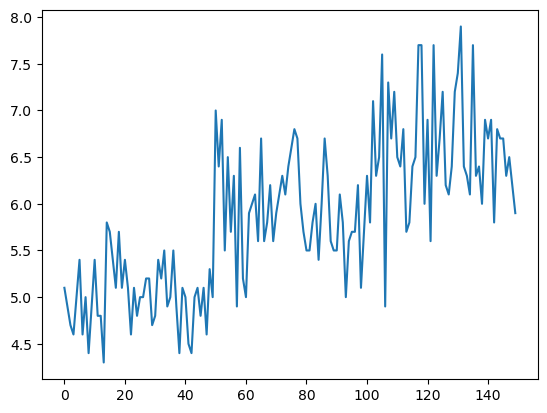

In [30]:
iris_df["sepal_length"].plot()
plt.show()

✅ You should now see your first plot.

## 🧑‍🎓Your turn:

🤔️ Is this a good visualization?

Hint: You can judge it from the perspectives of the graph's content, axes, and appearance.

Your answer here ...

# 📖 Useful online resources

- **[pandas tutorial](https://www.w3schools.com/python/pandas/default.asp)** - from W3 Schools

- **[Matplotlib tutorial](https://www.w3schools.com/python/matplotlib_intro.asp)** - from W3 Schools